## **Vol Surface Construction, Heston Pricing & Calibration**

**New features demonstrated:**
- `qf.impliedVol`: Newton-Raphson implied BS volatility from a market price
- `qf.vsCreate` / `qf.vsImpliedVol` / `qf.vsTotalVar` / `qf.vsAtmVol`: 2-D vol surface with bilinear interpolation
- `qf.hestonCall` / `qf.hestonVol`: Heston (1993) pricing via Gil-Pelaez characteristic-function inversion
- `qf.hestonCalibrate`: Joint multi-maturity calibration via Gauss-Newton with LM damping

**Outline**
1. Implied vol round-trip check
2. Build a market vol surface from Heston-generated quotes
3. Surface queries: interpolation, ATM vol, total variance
4. Heston pricing and smile comparison
5. Heston calibration and residual analysis
6. Question 1: Effect of vol-of-vol xi on the smile
7. Question 2: Effect of correlation rho on the skew

In [1]:
import qflib as qf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

plt.style.use('ggplot')
print('qflib version:', qf.version())
print('pid:', os.getpid())

qflib version: 1.2.0-debug
pid: 29076


### **CHECK 01: Implied Vol Round-Trip**

Price a European call/put with `qf.euroBS` at a known sigma, then recover sigma from the
price with `qf.impliedVol`.  The Newton-Raphson solver converges to machine precision.

In [2]:
S     = 100.0
r     = 0.05
q_div = 0.02
T     = 1.0
sig   = 0.25   # known vol

strikes_rt = [80, 90, 95, 100, 105, 110, 120]

print(f"{'K':>5}  {'Type':>5}  {'Price':>10}  {'Impl.Vol':>10}  {'Error':>12}")
for K in strikes_rt:
    for phi, lbl in [(1, 'call'), (-1, 'put')]:
        price = qf.euroBS(phi, S, K, T, r, q_div, sig)[0]
        ivol  = qf.impliedVol(phi, S, K, T, r, q_div, price)
        print(f'{K:>5d}  {lbl:>5}  {price:>10.6f}  {ivol:>10.6f}  {ivol - sig:>+12.2e}')

    K   Type       Price    Impl.Vol         Error
   80   call   23.669043    0.250000     +3.94e-15
   80    put    1.747530    0.250000     +3.83e-15
   90   call   16.635810    0.250000     +4.49e-12
   90    put    4.226591    0.250000     +4.49e-12
   95   call   13.684728    0.250000     +2.33e-15
   95    put    6.031656    0.250000     +2.22e-15
  100   call   11.123762    0.250000     -4.95e-12
  100    put    8.226837    0.250000     -4.95e-12
  105   call    8.941176    0.250000     -1.11e-11
  105    put   10.800398    0.250000     -1.11e-11
  110   call    7.112102    0.250000     -8.33e-17
  110    put   13.727472    0.250000     +4.44e-16
  120   call    4.374922    0.250000     +2.54e-11
  120    put   20.502586    0.250000     +2.54e-11


### **CHECK02: Build a Market Vol Surface**

We generate a implied vol surface by evaluating `qf.hestonVol` at a grid of
strikes x maturities with known "true" Heston parameters.  The surface is stored in
the market singleton with `qf.vsCreate`.

In [3]:
# True Heston parameters used to generate market quotes
true_p = {'v0': 0.04, 'kappa': 2.0, 'theta': 0.04, 'xi': 0.5, 'rho': -0.70}

S, r, q_div = 100.0, 0.05, 0.02

strikes_mkt    = np.array([75.0, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125])
maturities_mkt = np.array([0.25, 0.5, 1.0, 2.0])
nK, nT         = len(strikes_mkt), len(maturities_mkt)

mkt_vols = np.zeros((nK, nT))
p = true_p
for j, T_j in enumerate(maturities_mkt):
    F_j = S * np.exp((r - q_div) * T_j)
    for i, K_i in enumerate(strikes_mkt):
        phi = 1 if K_i <= F_j else -1    # use ITM option for numerical stability
        mkt_vols[i, j] = qf.hestonVol(
            phi, S, K_i, T_j, r, q_div,
            p['v0'], p['kappa'], p['theta'], p['xi'], p['rho']
        )

header = '  '.join(f'T={t:.2f}' for t in maturities_mkt)
print(f"{'K':>7}  {header}")
for i, K in enumerate(strikes_mkt):
    row = '  '.join(f'{mkt_vols[i,j]:>8.4f}' for j in range(nT))
    print(f'{K:>7.1f}  {row}')

      K  T=0.25  T=0.50  T=1.00  T=2.00
   75.0    0.2813    0.2681    0.2493    0.2310
   80.0    0.2646    0.2527    0.2365    0.2221
   85.0    0.2475    0.2370    0.2239    0.2136
   90.0    0.2299    0.2211    0.2115    0.2054
   95.0    0.2114    0.2049    0.1993    0.1975
  100.0    0.1922    0.1886    0.1875    0.1900
  105.0    0.1731    0.1729    0.1762    0.1828
  110.0    0.1577    0.1593    0.1658    0.1760
  115.0    0.1496    0.1495    0.1568    0.1696
  120.0    0.1474    0.1443    0.1495    0.1638
  125.0    0.1482    0.1428    0.1442    0.1584


In [4]:
qf.mktClear()
qf.ycCreate('YC', list(maturities_mkt) + [5.0], [r] * 5, 0)

vs_name = qf.vsCreate('MKTSURF', list(strikes_mkt), list(maturities_mkt), mkt_vols.tolist())
print('Created vol surface:', vs_name)
print('Market contents:    ', qf.mktList())

Created vol surface: MKTSURF
Market contents:     {'YieldCurves': ['YC'], 'Volatilities': [], 'VolSurfaces': ['MKTSURF']}


### **CHECK03: Surface Queries**

#### Interpolation Check

`qf.vsImpliedVol` uses bilinear interpolation and clamps to boundary values outside the grid.
At grid nodes the interpolated value should match the input exactly.

In [5]:
print(f"{'K':>7}  {'T':>5}  {'Market':>10}  {'Interp':>10}  {'Diff':>12}")
for j in [0, 2]:                       # T = 0.25 and 1.0
    T_j = maturities_mkt[j]
    for i in [0, 5, 10]:               # K = 75, 100, 125
        mkt    = mkt_vols[i, j]
        interp = qf.vsImpliedVol('MKTSURF', strikes_mkt[i], T_j)
        print(f'{strikes_mkt[i]:>7.1f}  {T_j:>5.2f}  {mkt:>10.4f}  {interp:>10.4f}  {interp - mkt:>+12.2e}')

      K      T      Market      Interp          Diff
   75.0   0.25      0.2813      0.2813     +0.00e+00
  100.0   0.25      0.1922      0.1922     +0.00e+00
  125.0   0.25      0.1482      0.1482     +0.00e+00
   75.0   1.00      0.2493      0.2493     +0.00e+00
  100.0   1.00      0.1875      0.1875     +0.00e+00
  125.0   1.00      0.1442      0.1442     +0.00e+00


#### ATM Vol and Total Variance Term Structure

In [6]:
print(f"{'T':>5}  {'Forward':>8}  {'ATM vol':>10}  {'Total var':>10}")
for T_j in maturities_mkt:
    fwd  = S * np.exp((r - q_div) * T_j)
    avol = qf.vsAtmVol('MKTSURF', T_j, fwd)
    tvar = qf.vsTotalVar('MKTSURF', fwd, T_j)
    print(f'{T_j:>5.2f}  {fwd:>8.3f}  {avol:>10.4f}  {tvar:>10.6f}')

    T   Forward     ATM vol   Total var
 0.25   100.753      0.1893    0.008959
 0.50   101.511      0.1839    0.016908
 1.00   103.045      0.1806    0.032623
 2.00   106.184      0.1812    0.065643


#### Surface Visualisation

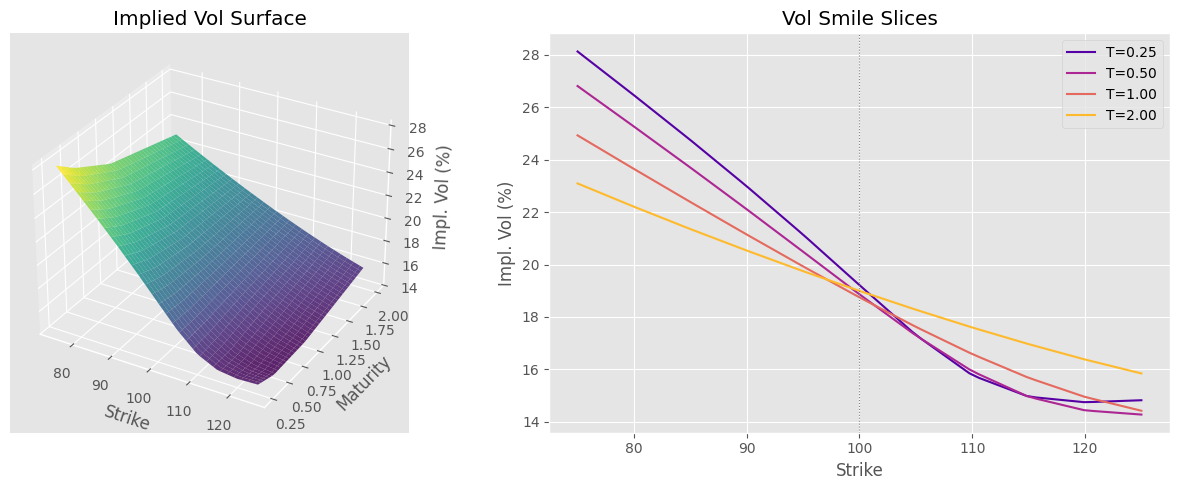

In [7]:
K_plot = np.linspace(strikes_mkt[0], strikes_mkt[-1], 60)
T_plot = np.linspace(maturities_mkt[0], maturities_mkt[-1], 40)
KK, TT = np.meshgrid(K_plot, T_plot)
VOL    = np.array([[qf.vsImpliedVol('MKTSURF', k, t) for k in K_plot] for t in T_plot])

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(KK, TT, VOL * 100, cmap='viridis', alpha=0.85)
ax1.set_xlabel('Strike'); ax1.set_ylabel('Maturity'); ax1.set_zlabel('Impl. Vol (%)')
ax1.set_title('Implied Vol Surface')

ax2 = fig.add_subplot(122)
colors = plt.cm.plasma(np.linspace(0.15, 0.85, nT))
for j, (T_j, c) in enumerate(zip(maturities_mkt, colors)):
    smile = [qf.vsImpliedVol('MKTSURF', k, T_j) * 100 for k in K_plot]
    ax2.plot(K_plot, smile, color=c, label=f'T={T_j:.2f}')
ax2.axvline(S, color='gray', linestyle=':', lw=0.8)
ax2.set_xlabel('Strike'); ax2.set_ylabel('Impl. Vol (%)')
ax2.set_title('Vol Smile Slices'); ax2.legend()

plt.tight_layout()
plt.savefig('vol_surface.png', dpi=150, bbox_inches='tight')
plt.show()


### **CHECK04: Heston Pricing**

The Heston (1993) dynamics:

$$dS = (r-q)S\,dt + \sqrt{v}\,S\,dW_1$$
$$dv = \kappa(\theta - v)\,dt + \xi\sqrt{v}\,dW_2, \qquad \langle dW_1,dW_2 \rangle = \rho\,dt$$

`qf.hestonCall` uses the Gil-Pelaez inversion formula with composite Simpson quadrature
(N=200 points, U_max=100).  `qf.hestonVol` inverts the result back to Black-Scholes implied vol.

In [8]:
T_cmp  = 1.0
bs_vol = np.sqrt(true_p['theta'])   # sqrt of long-run variance for BS comparison
F1     = S * np.exp((r - q_div) * T_cmp)

print(f"True params: v0={true_p['v0']}, kappa={true_p['kappa']}, theta={true_p['theta']}, xi={true_p['xi']}, rho={true_p['rho']}")
print(f"BS flat vol = sqrt(theta) = {bs_vol:.4f}\n")
print(f"{'K':>5}  {'Heston call':>13}  {'BS call':>13}  {'Diff':>10}  {'H-impl.vol':>12}")

p = true_p
for K in strikes_mkt:
    hcall = qf.hestonCall(S, K, T_cmp, r, q_div,
                          p['v0'], p['kappa'], p['theta'], p['xi'], p['rho'])
    bcall = qf.euroBS(1, S, K, T_cmp, r, q_div, bs_vol)[0]
    hvol  = qf.hestonVol(1 if K <= F1 else -1, S, K, T_cmp, r, q_div,
                         p['v0'], p['kappa'], p['theta'], p['xi'], p['rho'])
    print(f'{K:>5.1f}  {hcall:>13.6f}  {bcall:>13.6f}  {hcall - bcall:>+10.6f}  {hvol:>12.4f}')

True params: v0=0.04, kappa=2.0, theta=0.04, xi=0.5, rho=-0.7
BS flat vol = sqrt(theta) = 0.2000

    K    Heston call        BS call        Diff    H-impl.vol
 75.0      27.674666      27.075658   +0.599009        0.2493
 80.0      23.400519      22.764125   +0.636393        0.2365
 85.0      19.310438      18.752523   +0.557915        0.2239
 90.0      15.459430      15.123708   +0.335722        0.2115
 95.0      11.914277      11.938528   -0.024251        0.1993
100.0       8.752596       9.227006   -0.474409        0.1875
105.0       6.056984       6.986920   -0.929935        0.1762
110.0       3.899685       5.188582   -1.288896        0.1658
115.0       2.314880       3.783158   -1.468277        0.1568
120.0       1.267895       2.711776   -1.443881        0.1495
125.0       0.650353       1.913445   -1.263092        0.1442


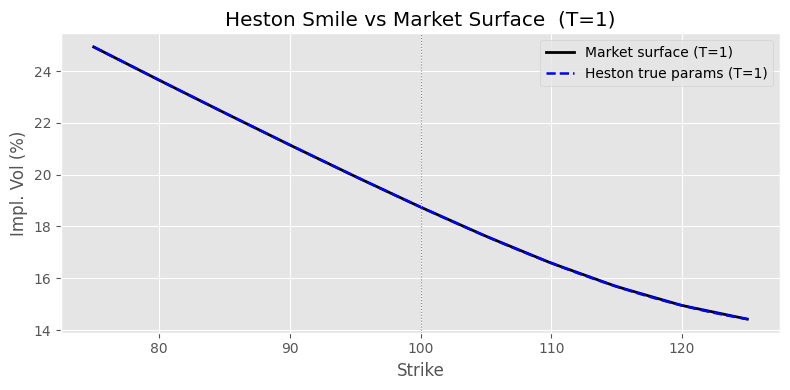

In [9]:
# Overlay Heston smile on market surface at T=1 (should be identical since surface was generated from same params)
T_j   = 1.0
h_sm  = [qf.hestonVol(1 if K <= F1 else -1, S, K, T_j, r, q_div,
                       p['v0'], p['kappa'], p['theta'], p['xi'], p['rho']) for K in K_plot]
m_sm  = [qf.vsImpliedVol('MKTSURF', K, T_j) for K in K_plot]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_plot, np.array(m_sm) * 100, 'k-',  lw=2,   label='Market surface (T=1)')
ax.plot(K_plot, np.array(h_sm) * 100, 'b--', lw=1.8, label='Heston true params (T=1)')
ax.axvline(S, color='gray', linestyle=':', lw=0.8)
ax.set_xlabel('Strike'); ax.set_ylabel('Impl. Vol (%)')
ax.set_title('Heston Smile vs Market Surface  (T=1)')
ax.legend()
plt.tight_layout()
plt.savefig('heston_smile_T1.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Heston Calibration

`qf.hestonCalibrate` fits all five parameters jointly to the nK x nT market vol matrix
using a Gauss-Newton solver with Levenberg-Marquardt damping.  We start from a perturbed
initial guess and verify we recover the true parameters.

In [10]:
x0 = {'v0': 0.06, 'kappa': 1.0, 'theta': 0.06, 'xi': 0.3, 'rho': -0.5}

fit = qf.hestonCalibrate(
    mkt_vols.tolist(), list(strikes_mkt), list(maturities_mkt),
    S, r, q_div,
    x0['v0'], x0['kappa'], x0['theta'], x0['xi'], x0['rho']
)

print('Calibration results:')
print(f"{'Param':>8}  {'True':>10}  {'x0':>10}  {'Fitted':>10}")
for key in ['v0', 'kappa', 'theta', 'xi', 'rho']:
    print(f"{key:>8}  {true_p[key]:>10.4f}  {x0[key]:>10.4f}  {fit[key.capitalize()]:>10.4f}")

Calibration results:
   Param        True          x0      Fitted
      v0      0.0400      0.0600      0.0400
   kappa      2.0000      1.0000      2.0000
   theta      0.0400      0.0600      0.0400
      xi      0.5000      0.3000      0.5000
     rho     -0.7000     -0.5000     -0.7000


In [11]:
# Residual table: calibrated Heston vol minus market vol
print('Residuals (Heston_fit - market) in vol pts:')
header = '  '.join(f'T={t:.2f}' for t in maturities_mkt)
print(f"{'K':>7}  {header}")

sse = 0.0
for i, K in enumerate(strikes_mkt):
    row_parts = []
    for j, T_j in enumerate(maturities_mkt):
        F_j  = S * np.exp((r - q_div) * T_j)
        phi  = 1 if K <= F_j else -1
        hvol = qf.hestonVol(phi, S, K, T_j, r, q_div,
                            fit['V0'], fit['Kappa'], fit['Theta'], fit['Xi'], fit['Rho'])
        diff = hvol - mkt_vols[i, j]
        sse += diff ** 2
        row_parts.append(f'{diff * 100:>+8.3f}%')
    print(f"{K:>7.1f}  {'  '.join(row_parts)}")

print(f'\nCalibration RMSE = {np.sqrt(sse / (nK * nT)) * 100:.4f}%')

Residuals (Heston_fit - market) in vol pts:
      K  T=0.25  T=0.50  T=1.00  T=2.00
   75.0    -0.000%    -0.000%    +0.000%    +0.000%
   80.0    -0.000%    -0.000%    +0.000%    +0.000%
   85.0    -0.000%    +0.000%    +0.000%    +0.000%
   90.0    -0.000%    +0.000%    +0.000%    +0.000%
   95.0    -0.000%    +0.000%    +0.000%    +0.000%
  100.0    +0.000%    +0.000%    +0.000%    -0.000%
  105.0    +0.000%    +0.000%    -0.000%    -0.000%
  110.0    +0.000%    +0.000%    -0.000%    -0.000%
  115.0    +0.000%    +0.000%    -0.000%    -0.000%
  120.0    +0.000%    +0.000%    -0.000%    -0.000%
  125.0    +0.000%    +0.000%    -0.000%    -0.000%

Calibration RMSE = 0.0000%


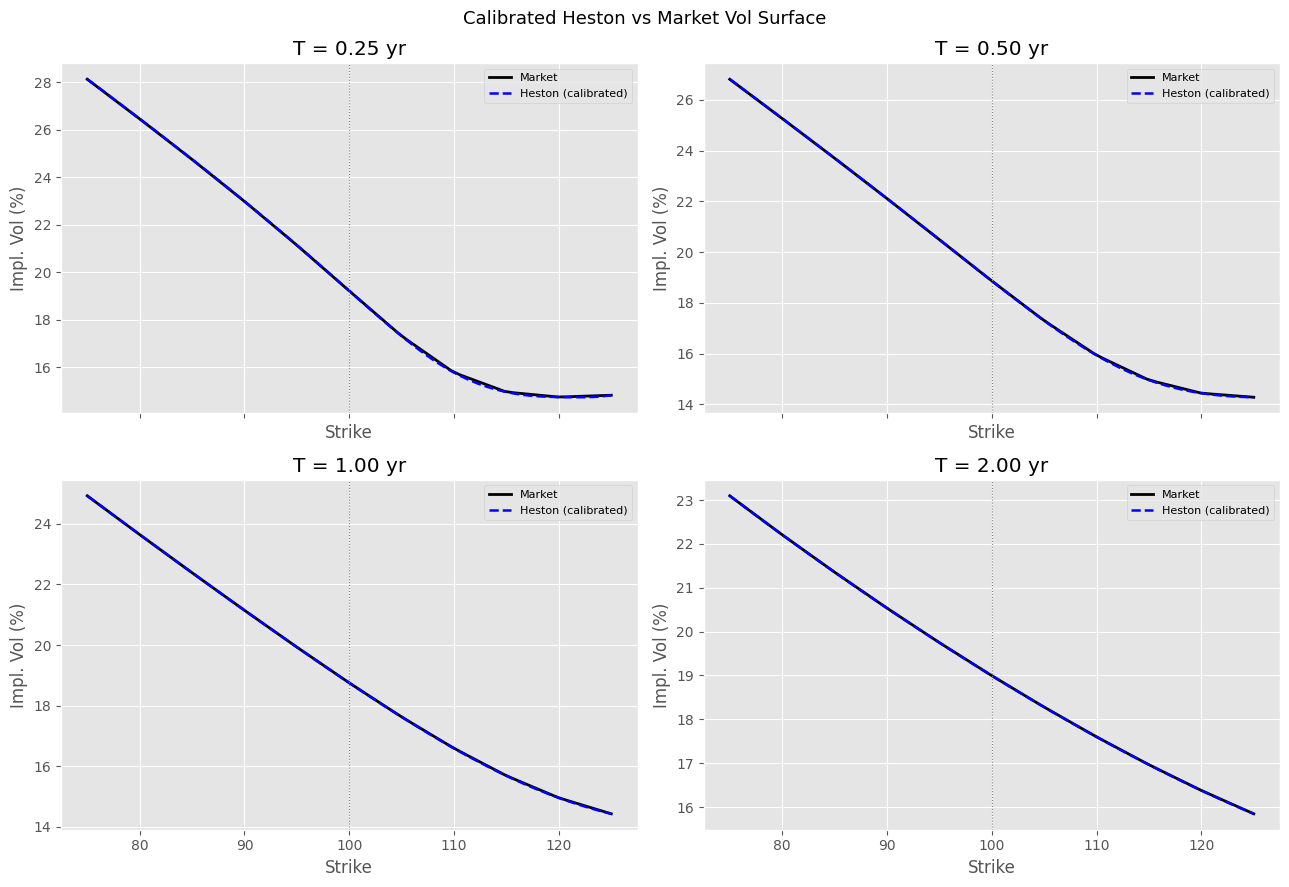

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.ravel()

for j, (T_j, ax) in enumerate(zip(maturities_mkt, axes)):
    F_j    = S * np.exp((r - q_div) * T_j)
    mkt_sm = [qf.vsImpliedVol('MKTSURF', K, T_j) * 100 for K in K_plot]
    fit_sm = [qf.hestonVol(1 if K <= F_j else -1, S, K, T_j, r, q_div,
                           fit['V0'], fit['Kappa'], fit['Theta'], fit['Xi'], fit['Rho']) * 100
              for K in K_plot]
    ax.plot(K_plot, mkt_sm, 'k-',  lw=2,   label='Market')
    ax.plot(K_plot, fit_sm, 'b--', lw=1.8, label='Heston (calibrated)')
    ax.axvline(S, color='gray', linestyle=':', lw=0.8)
    ax.set_title(f'T = {T_j:.2f} yr')
    ax.set_xlabel('Strike'); ax.set_ylabel('Impl. Vol (%)')
    ax.legend(fontsize=8)

fig.suptitle('Calibrated Heston vs Market Vol Surface', fontsize=13)
plt.tight_layout()
plt.savefig('heston_calibrated_smiles.png', dpi=150, bbox_inches='tight')
plt.show()